In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/datasets/Timor_dataset.zip"
extract_path = "/content/brain_tumor_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", os.listdir(extract_path))


Extracted to: ['Training', 'Testing']


In [ ]:
import os

print("Extracted path:", extract_path)
print("Subfolders:", os.listdir(extract_path))


Extracted path: /content/brain_tumor_data
Subfolders: ['Training', 'Testing']


In [ ]:
# Load dataset without creating a subset
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

class_names = train_ds.class_names
n_classes = len(class_names)
print("Classes:", class_names)

# Normalize images
normalizer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalizer(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y)).cache().prefetch(AUTOTUNE)


Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras import layers, models, optimizers

base_model = DenseNet201(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 157s 596ms/step - accuracy: 0.6100 - loss: 0.9386 - val_accuracy: 0.8093 - val_loss: 0.5105
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - accuracy: 0.8494 - loss: 0.4404 - val_accuracy: 0.8459 - val_loss: 0.4155
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 133ms/step - accuracy: 0.8728 - loss: 0.3459 - val_accuracy: 0.8650 - val_loss: 0.3639
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - accuracy: 0.8923 - loss: 0.2981 - val_accuracy: 0.8757 - val_loss: 0.3237
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 137ms/step - accuracy: 0.8947 - loss: 0.2692 - val_accuracy: 0.8902 - val_loss: 0.2850
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 136ms/step - accuracy: 0.9143 - loss: 0.2422 - val_accuracy: 0.8986 - val_loss: 0.2634
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - accuracy: 0.9199 - loss: 0.2238 - val_accuracy: 0.9092 - val_loss: 0.2457
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 42s 140ms/step - accuracy: 0.9311 - loss: 

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


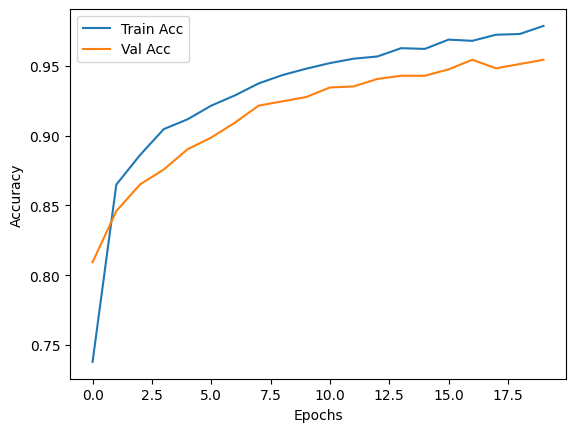

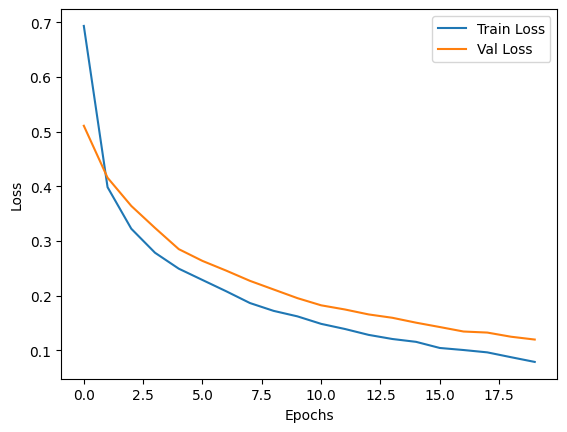

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
weights_path = "/content/drive/MyDrive/datasets/DenseNet201_Timor_20epochs.weights.h5"
model.save_weights(weights_path)
print(f"Weights saved at: {weights_path}")


Weights saved at: /content/drive/MyDrive/datasets/DenseNet201_Timor_20epochs.weights.h5


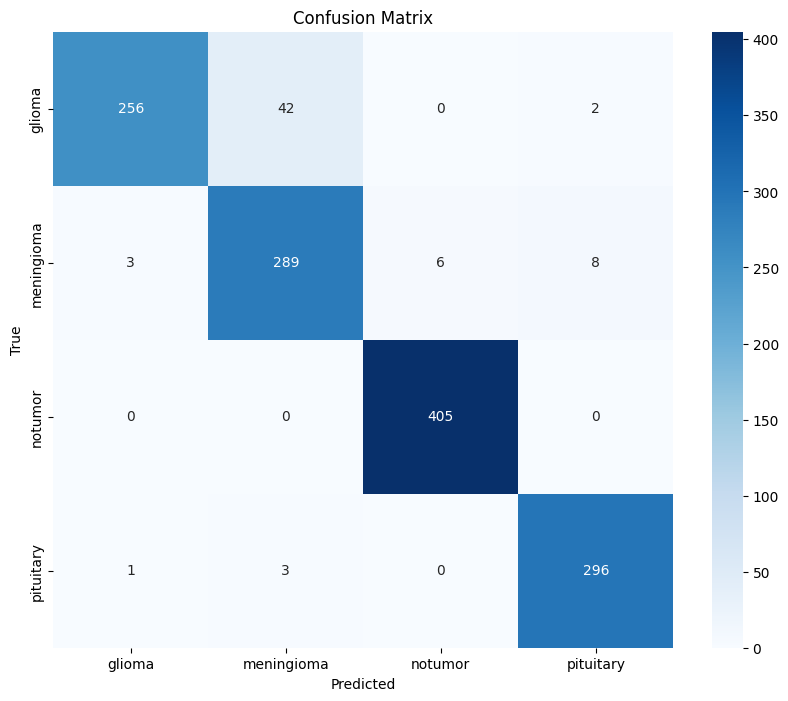

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.85      0.91       300
  meningioma       0.87      0.94      0.90       306
     notumor       0.99      1.00      0.99       405
   pituitary       0.97      0.99      0.98       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
weights_path = "/content/drive/MyDrive/datasets/DenseNet201_Timor.weights.h5"
model.save_weights(weights_path)
print(f" Weights saved at: {weights_path}")


 Weights saved at: /content/drive/MyDrive/datasets/DenseNet201_Timor.weights.h5
